In [ ]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn import datasets
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
import torch
import torch.nn as nn
import torch.nn.functional as f
import math

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
    def forward(self, x):
        return self.embedding(x)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe',pe)
    
    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:seq_len].unsqueeze(0)
        return x

In [ ]:
def scaled_dot_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    attn = f.softmax(scores, dim=-1)
    output = torch.matmul(attn, V)
    return output

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads
        self.num_heads = num_heads

        self.w_Q = nn.linear(d_model, d_model)
        self.w_K = nn.linear(d_model, d_model)
        self.w_V = nn.linear(d_model, d_model)

        self.w_O = nn.linear(d_model, d_model)
    
    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()

        Q = self.w_Q(x)
        K = self.w_K(x)
        V = self.w_V(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1,2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1,2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1,2)

        attn_out = scaled_dot_attention(Q, K, V, mask)

        concat = attn_out.transpose(1,2).contiguous().view(batch_size, seq_len, -1)

        return self.w_O(concat)

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.linear(d_model, d_ff)
        self.linear2 = nn.linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear1(x)
        x = self.dropout(x)
        x = f.relu(x)
        x = self.linear2(x)
        return x

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out = self.mha(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.token_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.token_emb(x)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

In [ ]:
class ClassificationHead(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, 1)

    def forward(self, x):
        cls_token = x[:, 0, :]
        logits = self.linear(cls_token)
        return torch.sigmoid(logits).squeeze(-1)

In [ ]:
class TransformerSentimentModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_layers=2, num_heads=4, d_ff=512, max_len=5000, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.head = ClassificationHead(d_model)

    def forward(self, x, mask=None):
        encoded = self.encoder(x, mask)
        return self.head(encoded)

In [ ]:
def train(model, dataloader, optimizer, criterion, epochs, device):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for batch_inputs, batch_labels in dataloader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad()
            out = model(batch_inputs)
            loss = criterion(out, batch_labels)
            loss.backward()
            optimizer.step()

In [ ]:
ds_train, ds_test = tfds.load(
    'imdb_reviews',
    split = ["train", 'test'],
    as_supervised=True,
    shuffle_files=True
)

#re type below later
train_texts = []
train_labels = []
for text, label in tfds.as_numpy(ds_train):
    train_texts.append(text.decode("utf-8"))
    train_labels.append(int(label))

test_texts = []
test_labels = []
for text, label in tfds.as_numpy(ds_test):
    test_texts.append(text.decode("utf-8"))
    test_labels.append(int(label))

# 3) Fit a Keras Tokenizer on the training texts
VOCAB_SIZE = 20000   # keep the top 20K words
OOV_TOKEN  = "<unk>"
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_texts)

# 4) Convert texts → sequences of word-indices
train_seqs = tokenizer.texts_to_sequences(train_texts)
test_seqs  = tokenizer.texts_to_sequences(test_texts)

# 5) Pad (or truncate) all sequences to the same length
MAX_LEN = 256
train_padded = pad_sequences(
    train_seqs,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    value=0         # corresponds to the '<pad>' index
)
test_padded = pad_sequences(
    test_seqs,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
    value=0
)

# 6) Build tf.data.Dataset pipelines
BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset
      .from_tensor_slices((train_padded, train_labels))
      .shuffle(buffer_size=10_000)
      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
      .from_tensor_slices((test_padded, test_labels))
      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
)



In [ ]:
# def animate_training(active, feat):
#     fig, ax = plt.subplots()
    
#     num_inputs = 784
#     num_hidden = 16
#     num_out = 10

#     input_nodes = [Ellipse((0, (i/28) * 4 - 22), width=0.25, height=2.5, color='green') for i in range(196, num_inputs-196, 28)]
#     hidden1_nodes = [Ellipse((3, i * 4 + 2), width=0.25, height=2.5, color='orange') for i in range(num_hidden)]
#     hidden2_nodes = [Ellipse((6, i * 4 + 2), width=0.25, height=2.5, color='blue') for i in range(num_hidden)]
#     out_nodes = [Ellipse((9, i * 6 + 6), width=0.4, height=4,facecolor='red', edgecolor='red', antialiased=False) for i in range(num_out)]

#     lines = []
#     connections = []
#     for i in range(len(input_nodes)):
#         for j in range(num_hidden):
#             connections.append((input_nodes[i], hidden1_nodes[j]))
#             line, = ax.plot([input_nodes[i].center[0], hidden1_nodes[j].center[0]], [input_nodes[i].center[1], hidden1_nodes[j].center[1]], color='grey', zorder=1, linewidth=.5)
#             lines.append(line)
    
#     for i in range(num_hidden):
#         for j in range(num_hidden):
#             connections.append((hidden1_nodes[i], hidden2_nodes[j]))
#             line, = ax.plot([hidden1_nodes[i].center[0], hidden2_nodes[j].center[0]], [hidden1_nodes[i].center[1], hidden2_nodes[j].center[1]], color='grey', zorder=1, linewidth=.5)
#             lines.append(line)
    
#     for i in range(num_hidden):
#         for j in range(num_out):
#             connections.append((hidden2_nodes[i], out_nodes[j]))
#             line, = ax.plot([hidden2_nodes[i].center[0], out_nodes[j].center[0]], [hidden2_nodes[i].center[1], out_nodes[j].center[1]], color='grey', zorder=1, linewidth=.5)
#             lines.append(line)

#     for node in input_nodes + hidden1_nodes + hidden2_nodes:
#         node.set_zorder(5)
#         ax.add_artist(node)

#     for i in range(len(out_nodes)):
#         out_nodes[i].set_zorder(5)
#         ax.add_artist(out_nodes[i])
#         ax.text(9, i * 6 + 6, str(i), ha='center', va='center', fontsize=12, fontweight='bold', color='black', zorder=10)

#     ax.set_xlim(-1,10)
#     ax.set_ylim(-1,64)
#     ax.set_xlabel('layer')
#     ax.set_ylabel('neuron')
#     #ax.legend()
#     title = ax.set_title("Update: 0")

#     def update(epoch):
#         X, H, H2, O, t = active[epoch]
#         for i in range(len(feat)):
#             if X[feat[i]] > 0:
#                 input_nodes[i].set_facecolor('green')
#             else:
#                 input_nodes[i].set_facecolor('grey')
        
#         for i in range(num_hidden):
#             if H[i] > 0.5:
#                 hidden1_nodes[i].set_facecolor('orange')
#             else:
#                 hidden1_nodes[i].set_facecolor('grey')
        
#         for i in range(num_hidden):
#             if H2[i] > 0.5:
#                 hidden2_nodes[i].set_facecolor('blue')
#             else:
#                 hidden2_nodes[i].set_facecolor('grey')
        
#         for node in out_nodes:
#             node.set_facecolor('grey')
#             node.set_edgecolor('grey')
#         pred = O.argmax()
#         out_nodes[pred].set_facecolor('red')
#         out_nodes[pred].set_edgecolor('red')

#         true = t.argmax()
        
#         if pred == true:
#             out_nodes[true].set_facecolor("#FF1C1C")
#             out_nodes[true].set_edgecolor('black')
            
#         else:
#             out_nodes[true].set_facecolor('grey')
#             out_nodes[true].set_edgecolor('black')
            

#         for ln, (nA, nB) in zip(lines, connections):
#             activeA = nA.get_facecolor() != mpl.colors.to_rgba('grey')
#             activeB = nB.get_facecolor() != mpl.colors.to_rgba('grey')
#             if activeA and activeB:
#                 ln.set_color('purple')
#                 ln.set_zorder(2)
#             else:
#                 ln.set_color('grey')
#                 ln.set_zorder(1)
#         title.set_text(f"Update: {epoch/500}")
#         return lines + input_nodes + hidden1_nodes + hidden2_nodes + out_nodes
#     ani = FuncAnimation(fig, update, frames=range(0, len(active), 500), interval=500, repeat=False)
#     plt.show()
#     return ani

0.098


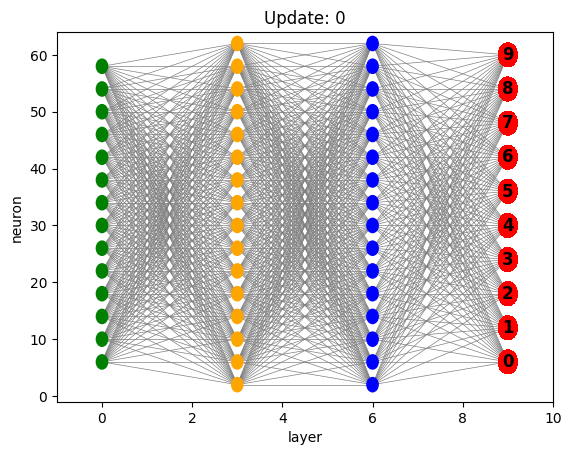

In [10]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255
enc = OneHotEncoder(sparse_output=False,categories='auto')
train_T = enc.fit_transform(train_labels.reshape(-1,1))
test_T = enc.fit_transform(test_labels.reshape(-1,1))
    
nn = NN(features=784, hidden_neurons=64, output_neurons=10, learning_rate=0.0001)

# train the network
cost = nn.train(train_images, train_T)

# make predictions on the test data
y_pred = nn.predict(test_images, test_T)
pred_labels = y_pred.argmax(axis=1)
accu = np.mean(pred_labels == test_labels)
print(accu)


all_dV = np.stack(nn.dV_hist, axis=0)
top14 = np.argsort(all_dV)[-14:]
top14.sort()
  
ani = animate_training(nn.active, feat=top14)
ani.save('testing.gif', writer='pillow', fps=2)